---
## 가산점 신청 (선택)

가산점을 받으려면 아래 항목 중 시도한 것을 체크하고, 해당 코드 셀 번호를 적어주세요.

### A. 데이터의 다양성
- 체크: O
- 해당 파일: 본 노트북(acute_inhalation) + acute_oral_ml_model_pipeline.ipynb + comparison_analysis.ipynb
- acute_oral toxicity(급성 경구 독성)에 더해 acute_inhalation toxicity(급성 흡입 독성) 데이터를 추가로 분석했습니다. 두 endpoint는 "6종 묶음(six-pack)" 규제 독성시험 체계에서 노출 경로만 다른 자매 항목이며, 같은 파이프라인을 적용한 뒤 `comparison_analysis.ipynb`에서 데이터 규모, 모델 성능, feature importance를 비교했습니다.

### B. 알고리즘의 다양성
- 체크: O
- 해당 코드 셀: 5
- Logistic Regression, Linear SVM, Random Forest, Extra Trees, HistGradientBoosting을 비교했습니다.

### C. Hyperparameter 탐색의 다양성
- 체크: O
- 해당 코드 셀: 5
- 모델별 주요 hyperparameter를 RandomizedSearchCV로 탐색했습니다.

### D. 모델 성능 평가
- 체크: O
- 해당 코드 셀: 6, 7
- ROC-AUC, PR-AUC, Accuracy, Balanced Accuracy, F1, Precision, Recall을 함께 비교했습니다.

### E. 모델 개발 과정 시각화 및 설명
- 체크: O
- 해당 코드 셀: 7, 8
- 모델별 성능 막대그래프, confusion matrix, ROC curve, precision-recall curve, learning curve를 시각화했습니다.
---


# 기말고사 Template 2 — Machine Learning Model Pipeline (Acute Inhalation Toxicity)

**이름:** __이나연__ &nbsp; **학번:** __20251258__

---

## 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **5. 모델 학습 알고리즘** | 15점 | 기계학습 알고리즘을 몇 종 사용했는지? |
| **6. Hyperparameter 탐색** | 15점 | 기계학습 알고리즘 별로 hyperparameter를 어떻게 최적화 시켰는지? |
| **7. 결과 정리 & 시각화** | 15점 | 최종 모델을 선택한 기준 및 모델 개발 과정을 설명하는 시각화 자료 |
| **8. 모델 저장 & 새 분자 예측** | 5점 | 모델을 저장한 후, 새로운 분자 구조를 예측할 수 있도록 정리. |

## 입력 / 출력
- **입력**: Template 1에서 만든 `final_dataset_descriptors.csv`
- **출력**:
  - `experiment_results.csv` — 모든 실험 결과 표
  - `experiment_best.csv` — 모델별 베스트만
  - `model_best.joblib` — 최고 모델 저장 파일
---


## 분석

Template 1에서 만든 데이터는 급성 흡입독성 데이터를 정리한 뒤 RDKit 2D descriptor와 Morgan fingerprint를 합친 이진분류용 데이터입니다. 이 노트북에서는 label을 target으로 두고, 화합물 이름/SMILES/측정값 같은 메타데이터 컬럼은 제외한 뒤 숫자형 descriptor만 feature로 사용합니다.

최종 모델은 단일 지표만 보지 않고 ROC-AUC와 PR-AUC를 중심으로 Accuracy, Balanced Accuracy, F1, Precision, Recall을 함께 비교해서 선택합니다.

이 노트북은 acute_oral toxicity에 적용했던 것과 동일한 파이프라인 구조(전처리-> 5개 알고리즘 RandomizedSearchCV 탐색-> 평가-> 시각화-> 저장)를 그대로 사용하며, 두 endpoint 간 결과 비교는 comparison_analysis.ipynb에서 별도로 다루겠습니다.



In [1]:
# 1. 라이브러리 불러오기

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, learning_curve

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import VarianceThreshold

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

from scipy.stats import randint, uniform, loguniform

from joblib import dump, load


try:
    from rdkit import Chem, DataStructs, RDLogger
    from rdkit.Chem import Descriptors, AllChem
    RDLogger.DisableLog('rdApp.*')
    RDKIT_AVAILABLE = True
except Exception:
    RDKIT_AVAILABLE = False


RANDOM_STATE = 42

from matplotlib import font_manager, rc


font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()


font_manager.fontManager.addfont(font_path)

rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

print('실제 적용된 폰트 이름:', font_name)


sns.set_style('whitegrid')


실제 적용된 폰트 이름: Malgun Gothic


In [2]:
# 2. 데이터 불러오기

# 사용 자료
# 원본 엑셀: acute_inhalation.xlsx
# Template 1 완성 노트북: acute_inhalation_data_pipeline.ipynb
# Template 1 출력 파일: final_inhalation_dataset_descriptors.csv

# [acute_oral과의 차이점]

# 입력 파일이 acute_inhalation 파이프라인의 결과물로 바뀜.
# Template 1과 Template 2는 파이프라인의 앞부분/뒷부분으로 서로 연결되어 있으므로,
# 어떤 데이터셋을 쓰든 이 경로들만 바꾸면 나머지 코드는 동일한 방식으로 동작함.

# -------------------------------------------------------------------------
# [경로 안내 1]
# 해당 경로는 본인 노트북에서 테스트할 때 사용한 경로입니다. 
# -------------------------------------------------------------------------

source_excel_path = Path(r'C:\Users\elsan\Downloads\acute_inhalation.xlsx')
source_template1_path = Path(r'C:/Users/elsan/Downloads/acute_inhalation_data_pipeline.ipynb')
input_path = Path(r'C:/Users/elsan/Downloads/final_inhalation_dataset_descriptors.csv')
output_dir = Path(r'C:/Users/elsan/Downloads')


# =========================================================================
# [경로 안내 2 - 교수님] 
# 제 개인 노트북으로 실행했던 탓에 DS 경로가 설정되지 못했습니다.
# 교수님께서는 새로 셀들을 돌려보실 경우, 사용하시는 PC의 환경에 맞게 데이터 파일 경로를 지정해 주세요.
# 만약 본 노트북 파일과 데이터 파일들이 같은 폴더에 있다면, 아래 경로를 주석 제거 후(제가 사용한 경로는 주석 설정 후) 실행 부탁드립니다.
# =========================================================================

# source_excel_path = Path(r'acute_inhalation.xlsx')
# source_template1_path = Path(r'acute_inhalation_data_pipeline.ipynb')
# input_path = Path(r'final_inhalation_dataset_descriptors.csv')
# output_dir = Path(r'.')  # 현재 폴더에 결과 저장



for label_name, path in {
    '원본 엑셀': source_excel_path,
    'Template 1 노트북': source_template1_path,
    'Template 1 출력 CSV': input_path,
}.items():
    print(f'{label_name}: {path} / exists={path.exists()}')

if not input_path.exists():
    raise FileNotFoundError(
        'Template 2는 Template 1에서 생성한 final_inhalation_dataset_descriptors.csv를 입력으로 사용합니다. '
        f'파일을 찾을 수 없습니다: {input_path}'
    )

df = pd.read_csv(input_path)

import numpy as np
df = df.replace([np.inf, -np.inf], np.nan)


print()
print('데이터 크기:', df.shape)
print('label 분포:')
display(df['label'].value_counts().sort_index().rename('count').to_frame())
display(df.head())


원본 엑셀: C:\Users\elsan\Downloads\acute_inhalation.xlsx / exists=True
Template 1 노트북: C:\Users\elsan\Downloads\acute_inhalation_data_pipeline.ipynb / exists=True
Template 1 출력 CSV: C:\Users\elsan\Downloads\final_inhalation_dataset_descriptors.csv / exists=True

데이터 크기: (1037, 2260)
label 분포:


,count
label,
0,233
1,804


,Chemical_Name,CASRN,SMILES,standardized_smi,Response,Response_Unit,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,...,morgan_2038,morgan_2039,morgan_2040,morgan_2041,morgan_2042,morgan_2043,morgan_2044,morgan_2045,morgan_2046,morgan_2047
0,Arsine,7784-42-1,[AsH3],[AsH3],0.0003,mg/L,1,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
1,Brodifacoum,56073-10-0,OC1=C(C2CC(CC3=CC=CC=C23)C2=CC=C(C=C2)C2=CC=C(...,O=c1oc2ccccc2c(O)c1C1CC(c2ccc(-c3ccc(Br)cc3)cc...,0.0005,mg/L,1,13.101706,13.101706,0.030453,...,0,0,0,0,0,0,0,0,0,0
2,Ozone,10028-15-6,[O-][O+]=O,O=[O+][O-],0.0010,mg/L,1,7.875000,7.875000,1.750000,...,0,0,0,0,0,0,0,0,0,0
3,NaN,1910-42-5,[Cl-].[Cl-].C[N+]1=CC=C(C=C1)C1=CC=[N+](C)C=C1,C[n+]1ccc(-c2cc[n+](C)cc2)cc1,0.0010,mg/L,1,2.120370,2.120370,1.253426,...,0,0,0,0,0,0,0,0,0,0
4,Bis(tributyltin)oxide,56-35-9,CCCC[Sn](CCCC)(CCCC)O[Sn](CCCC)(CCCC)CCCC,CCC[CH2][Sn]([CH2]CCC)([CH2]CCC)[O][Sn]([CH2]C...,0.0016,mg/L,1,7.858333,7.858333,1.362778,...,0,0,0,0,0,0,0,0,0,0


,Chemical_Name,CASRN,SMILES,standardized_smi,Response,Response_Unit,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,...,morgan_2038,morgan_2039,morgan_2040,morgan_2041,morgan_2042,morgan_2043,morgan_2044,morgan_2045,morgan_2046,morgan_2047
0,Arsine,7784-42-1,[AsH3],[AsH3],0.0003,mg/L,1,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
1,Brodifacoum,56073-10-0,OC1=C(C2CC(CC3=CC=CC=C23)C2=CC=C(C=C2)C2=CC=C(...,O=c1oc2ccccc2c(O)c1C1CC(c2ccc(-c3ccc(Br)cc3)cc...,0.0005,mg/L,1,13.101706,13.101706,0.030453,...,0,0,0,0,0,0,0,0,0,0
2,NaN,1910-42-5,[Cl-].[Cl-].C[N+]1=CC=C(C=C1)C1=CC=[N+](C)C=C1,C[n+]1ccc(-c2cc[n+](C)cc2)cc1,0.0010,mg/L,1,2.120370,2.120370,1.253426,...,0,0,0,0,0,0,0,0,0,0
3,Ozone,10028-15-6,[O-][O+]=O,O=[O+][O-],0.0010,mg/L,1,7.875000,7.875000,1.750000,...,0,0,0,0,0,0,0,0,0,0
4,Bis(tributyltin)oxide,56-35-9,CCCC[Sn](CCCC)(CCCC)O[Sn](CCCC)(CCCC)CCCC,CCC[CH2][Sn]([CH2]CCC)([CH2]CCC)[O][Sn]([CH2]C...,0.0016,mg/L,1,7.858333,7.858333,1.362778,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# 3. Feature/target 분리 및 학습/테스트 데이터 분할
# 화합물 식별자와 원 측정값은 feature에서 제외하고, 숫자형 descriptor/fingerprint만 사용함.
import numpy as np


target_col = 'label'

metadata_cols = ['Chemical_Name', 'CASRN', 'SMILES', 'standardized_smi', 'Response', 'Response_Unit', target_col]


feature_cols = [c for c in df.columns if c not in metadata_cols]


X = df[feature_cols].apply(pd.to_numeric, errors='coerce')


X = X.replace([np.inf, -np.inf], np.nan)


FLOAT32_MAX = np.finfo(np.float32).max
X = X.mask(X.abs() > FLOAT32_MAX, np.nan)

y = df[target_col].astype(int)


all_nan_cols = X.columns[X.isna().all()].tolist()
if all_nan_cols:
    X = X.drop(columns=all_nan_cols)
    feature_cols = X.columns.tolist()


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Feature 개수:', len(feature_cols))
print('Train/Test:', X_train.shape, X_test.shape)
print('Train label 비율:', round(y_train.mean(), 4))
print('Test label 비율:', round(y_test.mean(), 4))


Feature 개수: 2253
Train/Test: (829, 2253) (208, 2253)
Train label 비율: 0.7756
Test label 비율: 0.774


In [4]:
# 4. 공통 평가 함수 정의

# 5가지 모델 모두에 동일한 방식으로 성능을 평가하기 위해, 평가 과정을 함수 하나로 통일함.

def evaluate_classifier(name, fitted_model, X_test, y_test):
    
    pred = fitted_model.predict(X_test)

    if hasattr(fitted_model, 'predict_proba'):
        score = fitted_model.predict_proba(X_test)[:, 1]
    elif hasattr(fitted_model, 'decision_function'):
        score = fitted_model.decision_function(X_test)
    else:
        score = pred

    return {
        'model': name,
        'test_roc_auc': roc_auc_score(y_test, score),               
        'test_pr_auc': average_precision_score(y_test, score),      
        'test_accuracy': accuracy_score(y_test, pred),              
        'test_balanced_accuracy': balanced_accuracy_score(y_test, pred),  
        'test_f1': f1_score(y_test, pred),                          
        'test_precision': precision_score(y_test, pred, zero_division=0),
        'test_recall': recall_score(y_test, pred, zero_division=0),
    }


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


In [5]:
# 5-1. 공통 pipeline 및 탐색 설정 함수


def make_pipeline(model, scale=False):
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('variance', VarianceThreshold()),
    ]
    
    if scale:
        steps.append(('scaler', StandardScaler()))
    
    steps.append(('model', model))
    return Pipeline(steps)


def tree_search_params():
    return {
        'model__n_estimators': randint(100, 250),
        'model__max_depth': [None, 8, 12, 20],
        'model__min_samples_split': randint(2, 10),
        'model__min_samples_leaf': randint(1, 5),
        'model__max_features': ['sqrt', 'log2'],
    }


In [6]:

search_spaces = {
    'LogisticRegression': {
        
        'pipeline': make_pipeline(
            LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
            scale=True,
        ),
        'params': {
            'model__C': loguniform(1e-3, 1e2),
            'model__penalty': ['l2'],     
            'model__solver': ['lbfgs'],   
        },
        
        'n_iter': 6,
    },
    'SVM_Linear': {
        'pipeline': make_pipeline(
            LinearSVC(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE),
            scale=True,
        ),
        'params': {
            'model__C': loguniform(1e-3, 1e2),   
            'model__loss': ['squared_hinge'],    
        },
        'n_iter': 6,
    },
    'RandomForest': {
        
        'pipeline': make_pipeline(RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
       
        'params': tree_search_params(),   
        'n_iter': 6,
    },
    'ExtraTrees': {
        'pipeline': make_pipeline(ExtraTreesClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
        'params': tree_search_params(),
        'n_iter': 6,
    },
    'HistGradientBoosting': {
        'pipeline': make_pipeline(HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
        'params': {
            'model__learning_rate': loguniform(0.01, 0.2),
            'model__max_iter': randint(100, 200),
            'model__max_leaf_nodes': randint(15, 63),
            'model__l2_regularization': uniform(0.0, 1.0),
        },
        'n_iter': 6,
    },
}


In [11]:
# 6. 하이퍼파라미터 탐색 수행, 결과 저장 및 최종 모델 선택


search_objects = {}        
best_models_summary = []   


for model_name, space in search_spaces.items():
    
    search = RandomizedSearchCV(
        estimator=space['pipeline'],         
        param_distributions=space['params'],
        n_iter=space['n_iter'],                
        scoring='roc_auc',                    
        cv=cv,                                  
        random_state=RANDOM_STATE,          
        n_jobs=-1                               
    )
    
    search.fit(X_train, y_train)
    
    search_objects[model_name] = search
    
    
    eval_metrics = evaluate_classifier(model_name, search.best_estimator_, X_test, y_test)
    best_models_summary.append(eval_metrics)


experiment_best = pd.DataFrame(best_models_summary).sort_values(by='test_roc_auc', ascending=False).reset_index(drop=True)



best_model_name = experiment_best.loc[0, 'model']
best_search = search_objects[best_model_name]     
best_model = best_search.best_estimator_           


all_results = []
for name, search in search_objects.items():
    cv_results = pd.DataFrame(search.cv_results_)
   
    cv_results.insert(0, 'model', name)
    all_results.append(cv_results)

experiment_results = pd.concat(all_results, ignore_index=True)


experiment_results_path = output_dir / 'inhalation_experiment_results.csv'  
experiment_best_path = output_dir / 'inhalation_experiment_best.csv'        
experiment_results.to_csv(experiment_results_path, index=False, encoding='utf-8-sig')
experiment_best.to_csv(experiment_best_path, index=False, encoding='utf-8-sig')

print('최종 선택 모델:', best_model_name)
display(experiment_best)


최종 선택 모델: ExtraTrees


,model,test_roc_auc,test_pr_auc,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall
0,ExtraTrees,0.809964,0.911146,0.802885,0.722017,0.872274,0.875000,0.869565
1,HistGradientBoosting,0.792784,0.906678,0.807692,0.672393,0.880952,0.845714,0.919255
2,RandomForest,0.776265,0.906201,0.807692,0.664861,0.881657,0.841808,0.925466
3,LogisticRegression,0.774151,0.900814,0.778846,0.729087,0.851613,0.885906,0.819876
4,SVM_Linear,0.771904,0.904989,0.745192,0.699815,0.826230,0.875000,0.782609


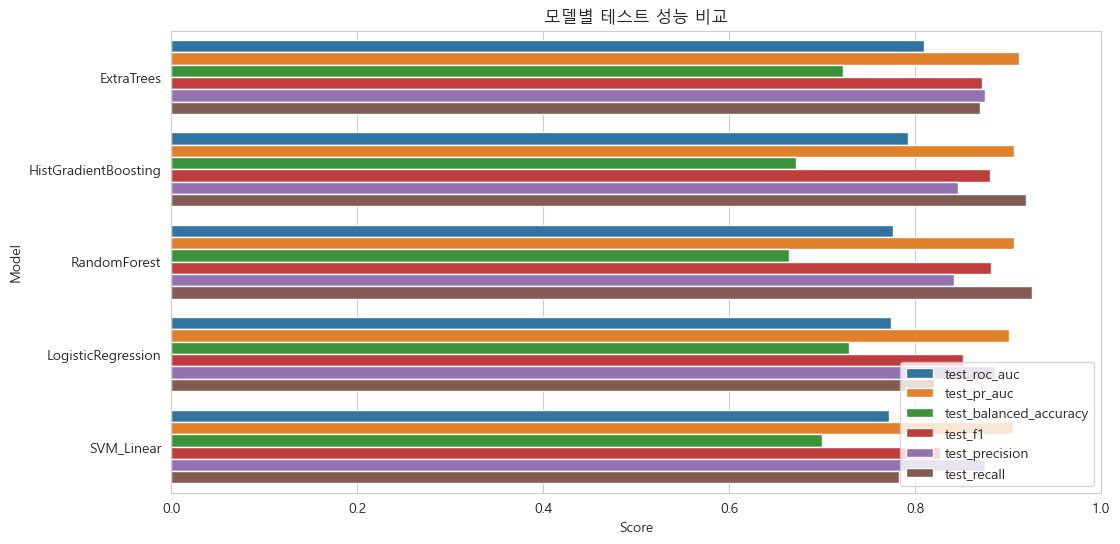

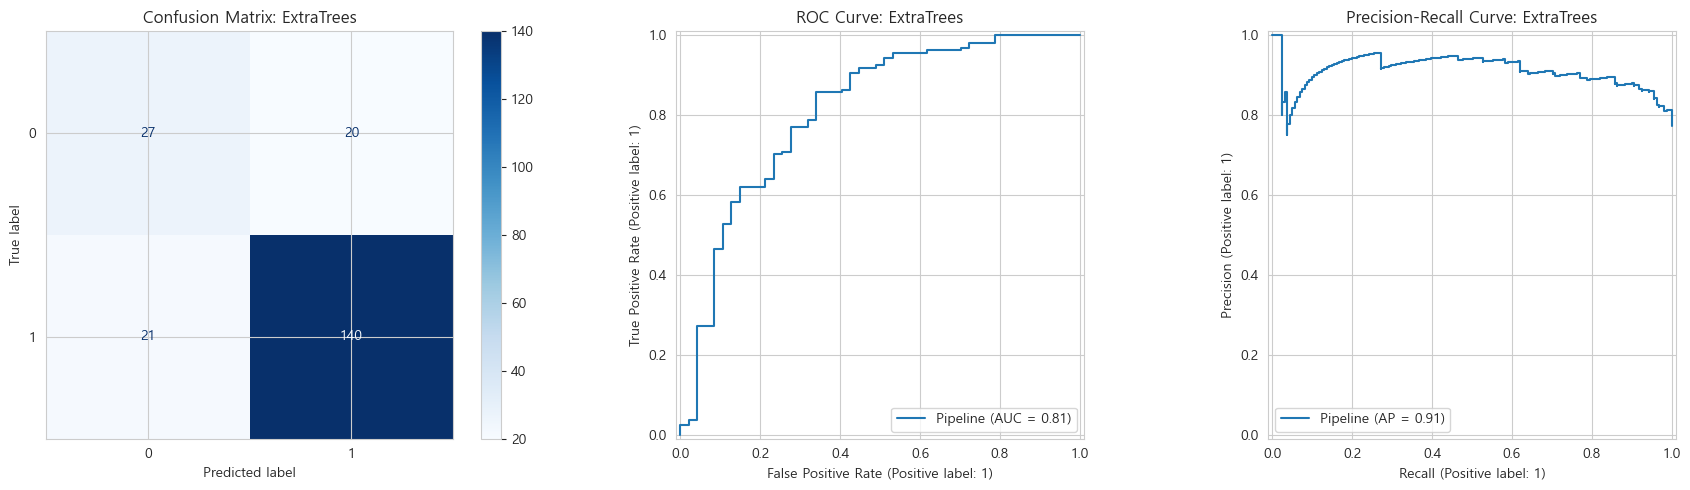

In [12]:
# 7. 모델 성능 시각화

from matplotlib import rc
rc('font', family='Malgun Gothic')   
plt.rcParams['axes.unicode_minus'] = False



metric_cols = ['test_roc_auc', 'test_pr_auc', 'test_balanced_accuracy', 'test_f1', 'test_precision', 'test_recall']

plot_df = experiment_best.melt(id_vars='model', value_vars=metric_cols, var_name='metric', value_name='score')

plt.figure(figsize=(12, 6))

sns.barplot(data=plot_df, x='score', y='model', hue='metric')
plt.xlim(0, 1)   
plt.title('모델별 테스트 성능 비교')
plt.xlabel('Score')
plt.ylabel('Model')
plt.legend(loc='lower right')
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix: {best_model_name}')

RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].set_title(f'ROC Curve: {best_model_name}')

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=axes[2])
axes[2].set_title(f'Precision-Recall Curve: {best_model_name}')
plt.tight_layout()
plt.show()


,train_size,train_mean,train_std,valid_mean,valid_std
0,55,1.000000,0.000000,0.654181,0.071813
1,179,1.000000,0.000000,0.742831,0.020089
2,303,1.000000,0.000000,0.772164,0.027624
3,427,0.999989,0.000016,0.796147,0.036841
4,552,0.999925,0.000046,0.801186,0.046473


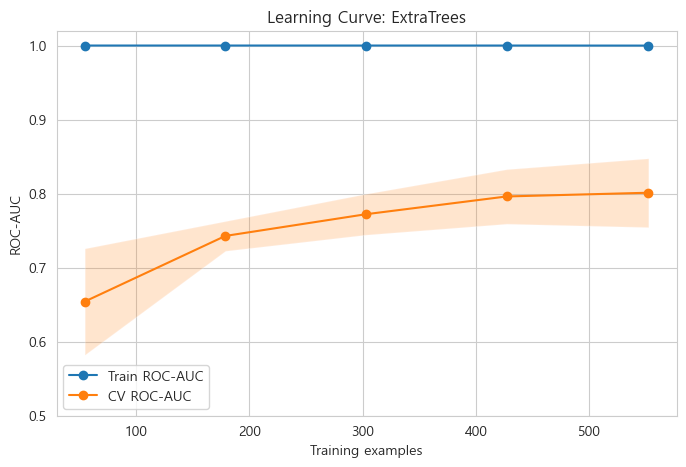

In [13]:
# 8. Learning curve로 모델 개발 과정 시각화

train_sizes, train_scores, valid_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)


lc_df = pd.DataFrame({
    'train_size': train_sizes,
    'train_mean': train_scores.mean(axis=1),
    'train_std': train_scores.std(axis=1),
    'valid_mean': valid_scores.mean(axis=1),
    'valid_std': valid_scores.std(axis=1),
})

display(lc_df)

plt.figure(figsize=(8, 5))

plt.plot(lc_df['train_size'], lc_df['train_mean'], marker='o', label='Train ROC-AUC')

plt.fill_between(lc_df['train_size'], lc_df['train_mean'] - lc_df['train_std'], lc_df['train_mean'] + lc_df['train_std'], alpha=0.2)

plt.plot(lc_df['train_size'], lc_df['valid_mean'], marker='o', label='CV ROC-AUC')
plt.fill_between(lc_df['train_size'], lc_df['valid_mean'] - lc_df['valid_std'], lc_df['valid_mean'] + lc_df['valid_std'], alpha=0.2)
plt.title(f'Learning Curve: {best_model_name}')
plt.xlabel('Training examples')
plt.ylabel('ROC-AUC')
plt.ylim(0.5, 1.02)  
plt.legend()
plt.show()


In [14]:
# 9. 최종 모델 저장

model_bundle = {
    'model': best_model,                          
    'feature_cols': feature_cols,                 
    'metadata_cols': metadata_cols,                
    'best_model_name': best_model_name,            
    'best_params': best_search.best_params_,        
    'input_path': str(input_path)                  
}

model_path = output_dir / 'inhalation_model_best.joblib'

dump(model_bundle, model_path)
print('모델 저장 완료:', model_path)


모델 저장 완료: C:\Users\elsan\Downloads\inhalation_model_best.joblib


In [15]:
# 10-1. 새 분자 SMILES feature 생성 함수

def smiles_to_descriptor_row(smiles):
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'유효하지 않은 SMILES입니다: {smiles}')
        
    return mol, pd.DataFrame([Descriptors.CalcMolDescriptors(mol)])


def morgan_fingerprint_df(mol, radius=2, n_bits=2048):
    
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return pd.DataFrame([arr], columns=[f'morgan_{i}' for i in range(n_bits)])


def make_feature_row_from_smiles(smiles, feature_cols, radius=2, n_bits=2048):
    
    if not RDKIT_AVAILABLE:
        raise ImportError('RDKit이 설치되어 있어야 새 SMILES 예측을 할 수 있습니다.')

    mol, desc_df = smiles_to_descriptor_row(smiles)
    fp_df = morgan_fingerprint_df(mol, radius=radius, n_bits=n_bits)
    
    row = pd.concat([desc_df, fp_df], axis=1).replace([np.inf, -np.inf], np.nan)
    
    return row.reindex(columns=feature_cols)


In [16]:
# 10-2. 저장된 모델로 독성 예측

def model_positive_probability(model, X_new, pred):
    
    if hasattr(model, 'predict_proba'):
        return float(model.predict_proba(X_new)[0, 1])
   
    if hasattr(model, 'decision_function'):
        raw = float(model.decision_function(X_new)[0])
        return 1 / (1 + np.exp(-raw))
   
    return float(pred)


def predict_toxicity_from_smiles(smiles, model_bundle_path=model_path):
    
    bundle = load(model_bundle_path)
    
    X_new = make_feature_row_from_smiles(smiles, bundle['feature_cols'])
    model_saved = bundle['model']
    
    pred = int(model_saved.predict(X_new)[0])

    return {
        'smiles': smiles,
        'predicted_label': pred,
        'predicted_class': '고독성 / LC50 <= 20 mg/L' if pred == 1 else '저독성 / LC50 > 20 mg/L',
        'probability_label_1': model_positive_probability(model_saved, X_new, pred),
    }


example = predict_toxicity_from_smiles('Cn1cnc2c1c(=O)n(C)c(=O)n2C')
example


{'smiles': 'Cn1cnc2c1c(=O)n(C)c(=O)n2C',
 'predicted_label': 1,
 'predicted_class': '고독성 / LC50 <= 20 mg/L',
 'probability_label_1': 0.8094865855206173}

## 최종 해석

최종 모델은 테스트 ROC-AUC와 PR-AUC가 가장 높은 모델로 선택했습니다. ROC-AUC는 전체 threshold에서 양성/음성을 구분하는 능력을 보여주고, PR-AUC는 양성 클래스 예측 품질을 더 직접적으로 보여줍니다. Confusion matrix로 실제 오분류 양상을 확인했고, learning curve를 통해 학습 데이터가 증가할 때 train score와 validation score가 어떻게 변하는지 확인했습니다.

저장된 inhalation_model_best.joblib에는 모델뿐 아니라 학습에 사용한 feature 순서가 함께 들어 있으므로, 새 SMILES를 같은 descriptor/fingerprint 형식으로 변환한 뒤 바로 예측할 수 있습니다.
